# 01 · Sensor-fusion validation — Madgwick vs the EKF

**Tasks 4.5 / 4.6.** Every number and figure here comes from `fusion.run_validation`, which scores
each filter over the full synthetic dataset (`make fusion`, or
`uv run python -m fusion.run_validation --data data/processed --figures paper/figures`). That run
takes ~20 minutes; this notebook **reads its results JSON** rather than recomputing, so it executes
in seconds and always shows exactly what the committed figures show.

## What is being measured

Each **noisy** record is run through each filter, per sensor (S2 upper arm / S4 forearm / S5 hand),
and compared sample-by-sample against the **analytic** ground-truth orientation rebuilt from that
record's own joint angles via `sim.arm3d.Arm3D.state()` — the same closed-form rotation the
simulator used to generate the IMU readings. Ground truth is never another filter run.

Two metrics, and the gap between them is where the interpretation lives:

| metric | what it is | observable? |
|---|---|---|
| **total** | angle of the relative rotation between estimate and truth | tilt **+** heading |
| **tilt** | angle between predicted and true gravity directions | **yes** — this is what the sensors can actually measure |

The reference IMU (ICM-42688-P, decision **D2**) has **no magnetometer**, so heading is unobservable
for *both* filters. A filter with perfect tilt and a large total error is not failing to track
gravity — it is drifting in a channel nothing in this pipeline can correct. Those are different
faults with opposite fixes, which is why both numbers are carried throughout.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Resolve the results file whether the notebook runs from the repo root or from notebooks/.
RESULTS = Path("paper/figures/fusion_validation.json")
if not RESULTS.exists():
    RESULTS = Path("..") / "paper" / "figures" / "fusion_validation.json"
if not RESULTS.exists():
    raise FileNotFoundError(
        "fusion_validation.json not found — run `make fusion` "
        "(uv run python -m fusion.run_validation) to generate it.")

R = json.loads(RESULTS.read_text())
CLASSES = ["reach", "lift", "wrist_rotate", "throw"]
PHASES = ["prep", "active", "settle"]
MAIN = ["madgwick", "ekf"]
ALL_KEYS = ["madgwick", "gyro_only", "ekf", "ekf_no_bias", "ekf_static_r"]
COLOR = {"madgwick": "#C44E52", "ekf": "#4C72B0", "gyro_only": "#8C8C8C",
         "ekf_no_bias": "#55A868", "ekf_static_r": "#CCB974"}
TRUTH = R["runs"]["truth"]
ACCEL = R["runs"]["accel"]

n_rec = R["dataset"]["n_noisy_records"]
n_samp = TRUTH["madgwick"]["overall"]["n"]
print(f"records scored: {n_rec}   |   sensor-samples: {n_samp:,}")
print("filters:", ", ".join(f"{k} = {v}" for k, v in R["filters"].items()))

records scored: 1000   |   sensor-samples: 2,887,500
filters: madgwick = Madgwick (β=0.1), ekf = EKF (bias state), gyro_only = gyro-only control, ekf_no_bias = EKF, bias state off, ekf_static_r = EKF, static R


## 1 · The headline table — RMS orientation error by motion class

In [2]:
def table(runs, metric="rms", keys=ALL_KEYS):
    head = f"{'filter':22s} {'overall':>8s} " + " ".join(f"{c:>13s}" for c in CLASSES)
    print(head); print("-" * len(head))
    for k in keys:
        r = runs[k]
        row = " ".join(f"{r['by_class'][c][metric]:13.3f}" for c in CLASSES)
        print(f"{r['label']:22s} {r['overall'][metric]:8.3f} {row}")

print("TOTAL orientation error (deg), initialised at the true attitude\n")
table(TRUTH, "rms")
print("\n\nTILT only (deg) — the observable component\n")
table(TRUTH, "tilt_rms")

TOTAL orientation error (deg), initialised at the true attitude

filter                  overall         reach          lift  wrist_rotate         throw
---------------------------------------------------------------------------------------
Madgwick (β=0.1)          2.609         1.498         2.237         1.452         5.099
gyro-only control         2.474         0.976         1.238         0.974         5.738
EKF (bias state)          2.195         1.489         1.066         1.049         4.798
EKF, bias state off       2.174         1.479         1.087         0.984         4.754
EKF, static R            33.467        62.615         8.379         3.798        21.962


TILT only (deg) — the observable component

filter                  overall         reach          lift  wrist_rotate         throw
---------------------------------------------------------------------------------------
Madgwick (β=0.1)          2.144         1.396         2.159         1.336         3.683
gyro-only

Read the first two rows first. **The EKF beats Madgwick on every motion class** — but the margin is
wildly uneven, and section 1b shows that the pooled RMS alone would have oversold `reach`.

Then read the `gyro-only control` row, which is what makes the result interpretable: a filter that
ignores the accelerometer entirely and does nothing but integrate the gyroscope **also** beats
Madgwick on the three non-`throw` classes. That is only possible if Madgwick's gravity correction
is *adding* error rather than removing drift — and it is, because the accelerometer measures
gravity **plus the sensor's own linear acceleration**, and Madgwick trusts it at a fixed rate
regardless of whether it is trustworthy at that instant.

### 1b · Is the margin real? A paired, per-trial test

Pooled RMS is one number over 2.9 M samples and it hides how *consistent* an advantage is. Each
filter's per-trial RMS is stored, so the honest comparison is paired: for each of the 250 trials in
a class, did the EKF beat Madgwick on that same trial? A Wilcoxon signed-rank test on those pairs
answers it without assuming normality.

In [3]:
from scipy import stats

print(f"{'class':14s} {'n':>4s} {'madgwick':>9s} {'ekf':>8s} {'median d':>10s} "
      f"{'EKF wins':>9s} {'Wilcoxon p':>12s}")
paired = {}
for c in CLASSES:
    m = np.array(TRUTH["madgwick"]["trial_rms"][c])
    e = np.array(TRUTH["ekf"]["trial_rms"][c])
    w = stats.wilcoxon(m, e)
    win = 100 * (e < m).mean()
    paired[c] = {"win": win, "p": w.pvalue, "median_d": float(np.median(e - m))}
    print(f"{c:14s} {len(m):4d} {m.mean():9.3f} {e.mean():8.3f} {np.median(e - m):+10.3f} "
          f"{win:8.1f}% {w.pvalue:12.2e}")

class             n  madgwick      ekf   median d  EKF wins   Wilcoxon p
reach           250     1.498    1.430     -0.192     62.4%     4.65e-03
lift            250     2.235    1.066     -1.165    100.0%     9.25e-43
wrist_rotate    250     1.451    1.033     -0.452     98.8%     1.65e-42
throw           250     4.645    4.438     -0.110     68.0%     1.53e-20


**The advantage is significant everywhere and consistent almost nowhere.** On `lift` the EKF wins
**100%** of trials and on `wrist_rotate` **98.8%** — those are not statistical results, they are
deterministic ones. On `throw` it wins 68% and on `reach` only **62.4%**: significant (p ≈ 5e-3)
but close to a coin flip trial by trial, and the pooled RMS margin on `reach` is a mere −0.6%.

Reporting "beats Madgwick on every class" without this table would be true and misleading. The
defensible claim is narrower: **the EKF is decisively better where the accelerometer is being
misled for a sustained period (`lift`, `wrist_rotate`), and barely distinguishable where it is
not (`reach`).** That is exactly what the dynamic-acceleration mechanism in section 4 predicts, so
the unevenness is corroboration rather than noise.

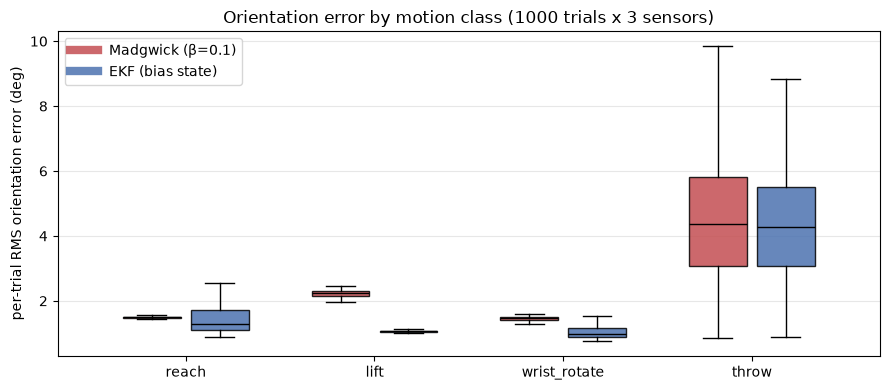

reach         Madgwick  1.498  ->  EKF  1.489   ( -0.6%)
lift          Madgwick  2.237  ->  EKF  1.066   (-52.3%)
wrist_rotate  Madgwick  1.452  ->  EKF  1.049   (-27.8%)
throw         Madgwick  5.099  ->  EKF  4.798   ( -5.9%)


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
width = 0.36
for k, key in enumerate(MAIN):
    data = [TRUTH[key]["trial_rms"][c] for c in CLASSES]
    pos = np.arange(len(CLASSES)) + (k - 0.5) * width
    bp = ax.boxplot(data, positions=pos, widths=width * 0.85, patch_artist=True,
                    showfliers=False, medianprops=dict(color="black"))
    for box in bp["boxes"]:
        box.set_facecolor(COLOR[key]); box.set_alpha(0.85)
    ax.plot([], [], color=COLOR[key], lw=6, alpha=0.85, label=TRUTH[key]["label"])
ax.set_xticks(np.arange(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_ylabel("per-trial RMS orientation error (deg)")
ax.set_title(f"Orientation error by motion class ({n_rec} trials x 3 sensors)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

for c in CLASSES:
    m, e = TRUTH["madgwick"]["by_class"][c]["rms"], TRUTH["ekf"]["by_class"][c]["rms"]
    print(f"{c:13s} Madgwick {m:6.3f}  ->  EKF {e:6.3f}   ({(e/m - 1) * 100:+5.1f}%)")

## 2 · Where in the motion the error lives

If the dynamic-acceleration explanation is right, the damage should be concentrated in the
**`active`** phase — the part of each trial where the arm is actually moving and the accelerometer
is therefore reading something other than gravity. `prep` and `settle` are at rest, where the
accelerometer is telling the truth and both filters should do well.

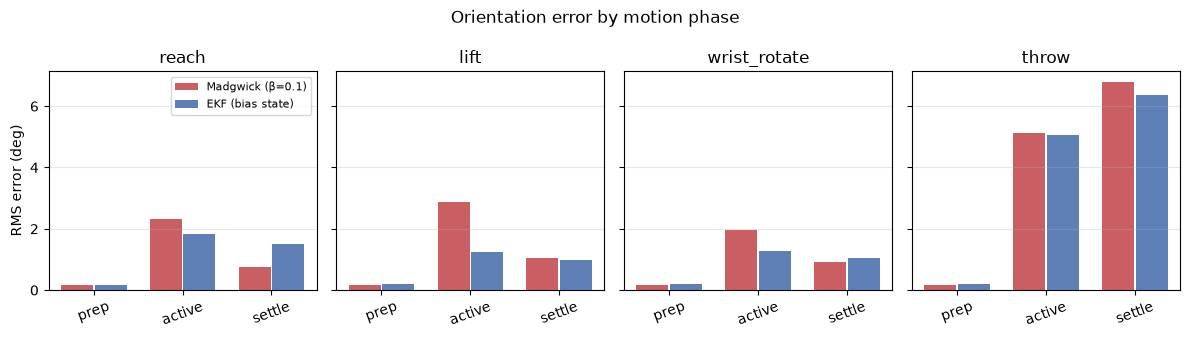

class         phase     Madgwick      EKF
reach         prep         0.166    0.183
reach         active       2.304    1.838
reach         settle       0.743    1.506
lift          prep         0.172    0.188
lift          active       2.883    1.245
lift          settle       1.036    0.988
wrist_rotate  prep         0.167    0.185
wrist_rotate  active       1.972    1.260
wrist_rotate  settle       0.908    1.041
throw         prep         0.172    0.191
throw         active       5.133    5.048
throw         settle       6.796    6.348


In [5]:
fig, ax = plt.subplots(1, len(CLASSES), figsize=(12, 3.4), sharey=True)
x = np.arange(len(PHASES))
for a, c in zip(ax, CLASSES):
    for k, key in enumerate(MAIN):
        vals = [TRUTH[key]["by_phase"][c].get(p, {}).get("rms", 0.0) for p in PHASES]
        a.bar(x + (k - 0.5) * 0.38, vals, 0.36, color=COLOR[key], alpha=0.9,
              label=TRUTH[key]["label"] if c == CLASSES[0] else None)
    a.set_xticks(x); a.set_xticklabels(PHASES, rotation=20)
    a.set_title(c); a.grid(axis="y", alpha=0.3)
ax[0].set_ylabel("RMS error (deg)"); ax[0].legend(fontsize=8)
fig.suptitle("Orientation error by motion phase")
plt.tight_layout(); plt.show()

print(f"{'class':13s} {'phase':8s} {'Madgwick':>9s} {'EKF':>8s}")
for c in CLASSES:
    for p in PHASES:
        m = TRUTH["madgwick"]["by_phase"][c].get(p, {}).get("rms")
        e = TRUTH["ekf"]["by_phase"][c].get(p, {}).get("rms")
        if m is not None:
            print(f"{c:13s} {p:8s} {m:9.3f} {e:8.3f}")

## 3 · Convergence — one trial per class, error against time

The shaded band is the `active` phase. Note the shape rather than the absolute level: Madgwick's
error *grows through the active phase and does not come back*, because the correction it applied
during the motion went partly into heading, which nothing can undo.

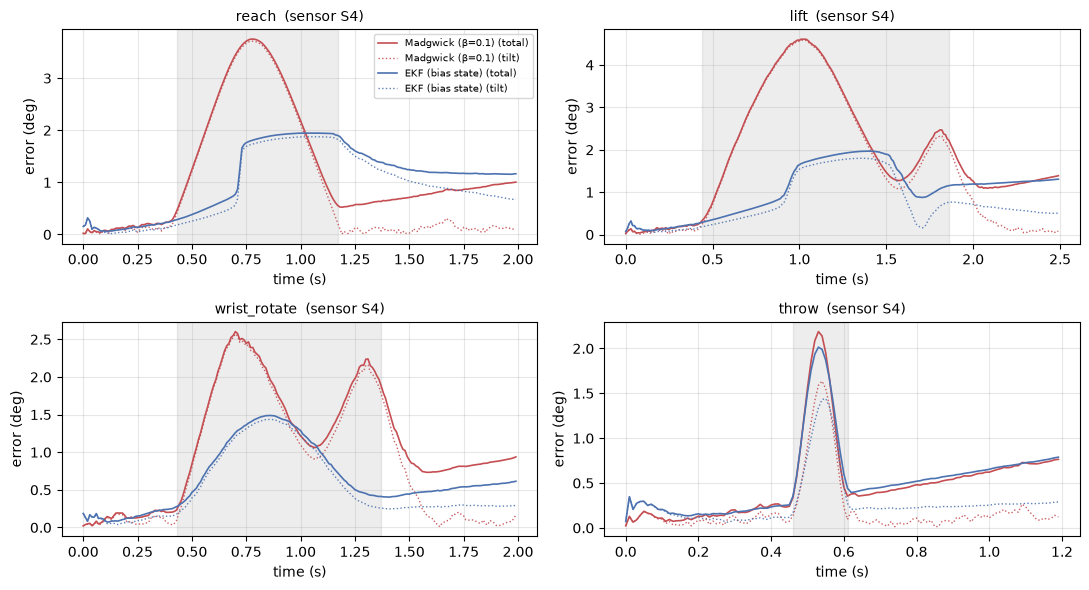

In [6]:
conv = R["convergence"]
fig, ax = plt.subplots(2, 2, figsize=(11, 6))
for a, c in zip(ax.ravel(), CLASSES):
    e = conv[c]; t = np.asarray(e["t"]); ph = np.asarray(e["phase"])
    for key in MAIN:
        a.plot(t, e[key], color=COLOR[key], lw=1.2, label=f"{TRUTH[key]['label']} (total)")
        a.plot(t, e[key + "_tilt"], color=COLOR[key], lw=1.0, ls=":", alpha=0.9,
               label=f"{TRUTH[key]['label']} (tilt)")
    act = ph == "active"
    if act.any():
        a.axvspan(t[act].min(), t[act].max(), color="black", alpha=0.07)
    a.set_title(f"{c}  (sensor {e['sensor']})", fontsize=10)
    a.set_xlabel("time (s)"); a.set_ylabel("error (deg)"); a.grid(alpha=0.3)
ax[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 4 · Ablations — what is actually producing the EKF's advantage

This is the part that matters most, and it contradicts the reason the EKF was commissioned.
Task 4.3 named the **gyro-bias state** as the suspected fix for `lift`. Two controls:

- **`EKF, bias state off`** — the bias state disabled entirely.
- **`EKF, static R`** — the dynamic-acceleration term removed from the measurement noise, leaving
  a conventional constant measurement covariance.

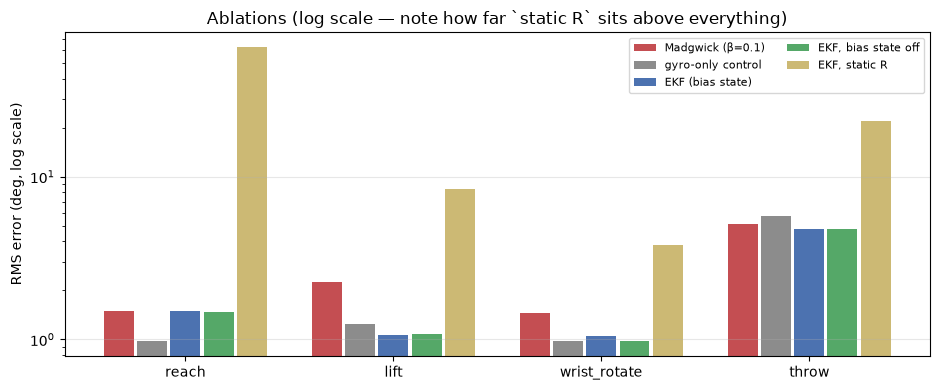

class              EKF   no bias    delta   static R  x worse
reach            1.489     1.479   -0.010     62.615    42.0x
lift             1.066     1.087   +0.020      8.379     7.9x
wrist_rotate     1.049     0.984   -0.065      3.798     3.6x
throw            4.798     4.754   -0.044     21.962     4.6x


In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4))
x = np.arange(len(CLASSES)); w = 0.16
for k, key in enumerate(ALL_KEYS):
    vals = [TRUTH[key]["by_class"][c]["rms"] for c in CLASSES]
    ax.bar(x + (k - 2) * w, vals, w * 0.9, color=COLOR[key], label=TRUTH[key]["label"])
ax.set_xticks(x); ax.set_xticklabels(CLASSES); ax.set_yscale("log")
ax.set_ylabel("RMS error (deg, log scale)")
ax.set_title("Ablations (log scale — note how far `static R` sits above everything)")
ax.legend(fontsize=8, ncol=2); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

ekf = TRUTH["ekf"]["by_class"]; nob = TRUTH["ekf_no_bias"]["by_class"]
sta = TRUTH["ekf_static_r"]["by_class"]
print(f"{'class':13s} {'EKF':>8s} {'no bias':>9s} {'delta':>8s} {'static R':>10s} {'x worse':>8s}")
for c in CLASSES:
    d = nob[c]["rms"] - ekf[c]["rms"]
    print(f"{c:13s} {ekf[c]['rms']:8.3f} {nob[c]['rms']:9.3f} {d:+8.3f} "
          f"{sta[c]['rms']:10.3f} {sta[c]['rms'] / ekf[c]['rms']:7.1f}x")

**Turning the gyro-bias state off changes almost nothing.** Removing the dynamic-acceleration term
makes the filter an order of magnitude worse than the Madgwick filter it was meant to improve on.

So the EKF's win is real but the credited mechanism is not: it comes from *knowing when not to
trust the accelerometer*, not from estimating gyro bias. The reason is trial length — the dataset's
motions run 1.2–2.5 s, and a 0.5 deg/s turn-on bias only integrates to about 1.25 deg over 2.5 s.
That is too small to matter here and, more importantly, too small to *identify* against an
accelerometer carrying several degrees of dynamic-acceleration error. Section 6 shows the horizon
on which the bias state does pay.

## 5 · Which channel is failing — tilt vs heading, and does initialisation matter?

Every number above seeds each filter with the **exact true initial orientation**. That is generous:
it hands the filter for free the one thing an accelerometer is unambiguously good at. The `accel`
initialisation instead seeds from the first accelerometer sample — tilt from measured gravity,
heading left at zero, which is what a real capture session gets.

Read the **tilt** column for the `accel` run. Its *total* column is dominated by a constant,
permanent, unknowable heading offset (several classes start with a non-zero heading — `reach` opens
with the elbow at 0.2 rad about the vertical, `wrist_rotate` at 0.6 rad), identical for every
filter and therefore uninformative about any of them.

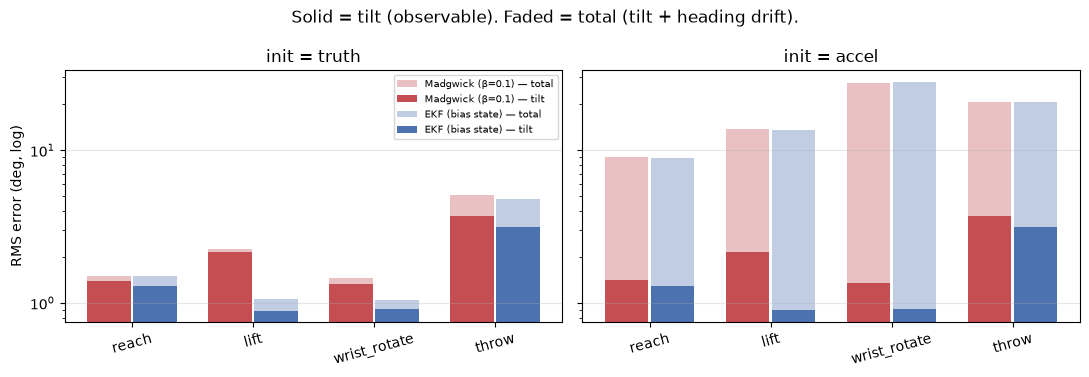

filter                  tilt @ truth-init  tilt @ accel-init
Madgwick (β=0.1)                    2.144              2.148
gyro-only control                   1.955              2.111
EKF (bias state)                    1.564              1.565
EKF, bias state off                 1.560              1.561
EKF, static R                       2.915              2.915


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
x = np.arange(len(CLASSES))
for a, (name, runs) in zip(ax, [("truth", TRUTH), ("accel", ACCEL)]):
    for k, key in enumerate(MAIN):
        tot = [runs[key]["by_class"][c]["rms"] for c in CLASSES]
        tilt = [runs[key]["by_class"][c]["tilt_rms"] for c in CLASSES]
        pos = x + (k - 0.5) * 0.38
        a.bar(pos, tot, 0.36, color=COLOR[key], alpha=0.35,
              label=f"{runs[key]['label']} — total" if name == "truth" else None)
        a.bar(pos, tilt, 0.36, color=COLOR[key],
              label=f"{runs[key]['label']} — tilt" if name == "truth" else None)
    a.set_xticks(x); a.set_xticklabels(CLASSES, rotation=15); a.set_yscale("log")
    a.set_title(f"init = {name}"); a.grid(axis="y", alpha=0.3)
ax[0].set_ylabel("RMS error (deg, log)"); ax[0].legend(fontsize=7)
fig.suptitle("Solid = tilt (observable). Faded = total (tilt + heading drift).")
plt.tight_layout(); plt.show()

print(f"{'filter':22s} {'tilt @ truth-init':>18s} {'tilt @ accel-init':>18s}")
for key in ALL_KEYS:
    print(f"{TRUTH[key]['label']:22s} {TRUTH[key]['overall']['tilt_rms']:18.3f} "
          f"{ACCEL[key]['overall']['tilt_rms']:18.3f}")

Two conclusions, both load-bearing:

1. **For every filter that uses the accelerometer, tilt error is unchanged between the two
   initialisations** — Madgwick +0.2%, EKF +0.1%, `EKF, bias state off` +0.1%, `EKF, static R`
   +0.0%. Initialisation moves only the unobservable channel, exactly what the physics predicts,
   which means the truth-initialised comparison above is *not* an artefact of a generous setup.
   This closes a caveat left open in `WORK/work11.md`.

   **The one exception proves the rule: `gyro-only` degrades by +8.0%** (1.955° → 2.111°). It is
   the only column with no accelerometer correction, so nothing ever pulls its tilt back towards
   gravity and the initial error simply persists for the whole trial. A filter that *does* use the
   accelerometer forgets its initial condition within a second; a filter that does not, never
   does. That is the value of the gravity correction stated in one number — and it is worth
   holding next to section 1, where the same correction is what makes Madgwick *worse* than
   integrating the gyro alone. The accelerometer fixes the initial condition and corrupts the
   motion; which effect wins depends entirely on how long you look.
2. **`EKF, static R` has respectable tilt and catastrophic total.** Its failure is almost entirely
   heading. That is the leak documented in `fusion/ekf.py`: with a small constant measurement
   noise, each correction is large, and a long sequence of large corrections about an axis that is
   itself rotating does not commute — the residue lands in the one direction the accelerometer
   cannot see, where nothing pulls it back. Confirmed here at dataset scale.

## 6 · Long horizon — where the gyro-bias state earns its place

Every trial in the dataset is 1.2–2.5 s. To probe the regime bias actually governs: take one real
trial, then keep the filters running through a stationary hold generated by the *same* D2 sensor
model, so the gyro keeps reporting its turn-on bias plus random walk.

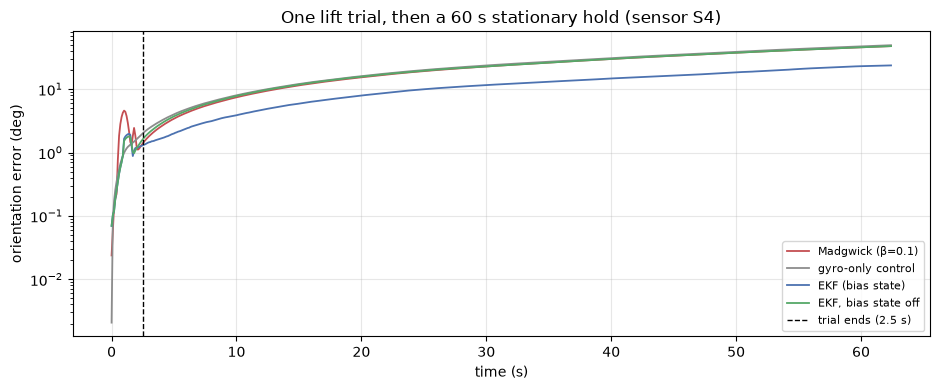

filter                  trial end     +10 s     +30 s     final
Madgwick (β=0.1)            1.395     9.454    24.501    47.841
gyro-only control           2.014    10.016    25.381    49.428
EKF (bias state)            1.305     4.905    12.311    23.685
EKF, bias state off         1.617     9.804    24.491    47.806


In [9]:
lh = R["long_horizon"]
t = np.asarray(lh["t"])
fig, ax = plt.subplots(figsize=(9.5, 4))
for key, d in lh["filters"].items():
    ax.plot(t, d["trace"], color=COLOR[key], lw=1.3, label=d["label"])
ax.axvline(lh["trial_end_s"], color="black", ls="--", lw=1,
           label=f"trial ends ({lh['trial_end_s']:.1f} s)")
ax.set_xlabel("time (s)"); ax.set_ylabel("orientation error (deg)"); ax.set_yscale("log")
ax.set_title(f"One {lh['motion_class']} trial, then a {lh['hold_s']:.0f} s stationary hold "
             f"(sensor {lh['sensor']})")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'filter':22s} {'trial end':>10s} {'+10 s':>9s} {'+30 s':>9s} {'final':>9s}")
for key, d in lh["filters"].items():
    print(f"{d['label']:22s} {d['at_trial_end']:10.3f} {d['at_10s']:9.3f} "
          f"{d['at_30s']:9.3f} {d['final']:9.3f}")

The bias state needs time to identify the bias, and once it has, it holds — compare `EKF` against
`EKF, bias state off` at +10 s. The gyro-only control shows what the accelerometer is genuinely
worth over a long horizon: without it, error grows without bound.

**Counter-evidence, kept rather than buried:** at the end of the hold Madgwick can come out ahead
of the EKF. In that regime the bias *random walk* dominates the constant offset, and Madgwick's very
aggressive fixed-rate tilt correction simply pins tilt error near zero. This is a single trial, not
a distribution, so nothing should be built on it — but it points the opposite way from the headline
and belongs on the record. The likely fix if it survives replication is a larger
`bias_rw_dps_sqrt_s`: the filter is currently told the *true* random-walk rate, which makes it slow
to track a walk it should be chasing rather than averaging.

## 7 · Noise sensitivity

Clean records re-corrupted with the D2 sensor model at scaled noise levels — every parameter (gyro
white noise, accelerometer white noise, turn-on bias, bias random walk) scaled by the same factor,
so `1.0` reproduces the shipped dataset and the curve reads as "how gracefully does each filter
degrade as the sensor gets cheaper".

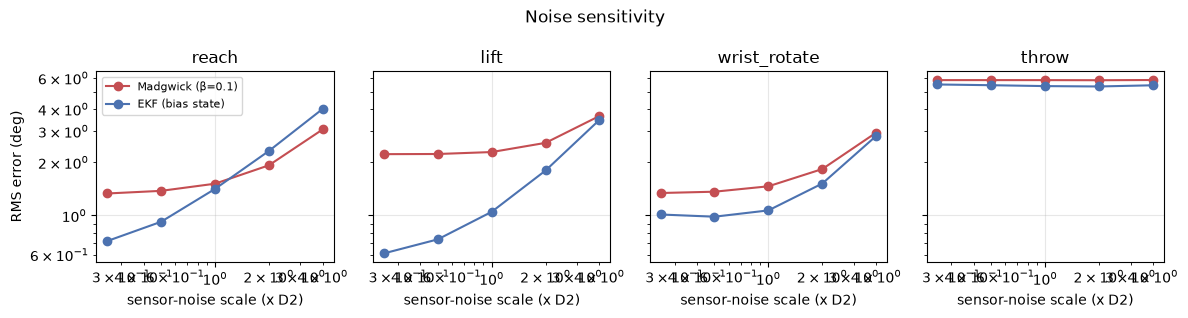

 scale                  reach                   lift           wrist_rotate                  throw
               Madgwick / EKF         Madgwick / EKF         Madgwick / EKF         Madgwick / EKF
  0.25      1.331 /    0.716      2.221 /    0.610      1.339 /    1.012      5.826 /    5.504
  0.50      1.377 /    0.921      2.226 /    0.732      1.362 /    0.983      5.826 /    5.451
  1.00      1.511 /    1.412      2.283 /    1.048      1.461 /    1.068      5.824 /    5.388
  2.00      1.921 /    2.315      2.573 /    1.795      1.829 /    1.515      5.817 /    5.362
  4.00      3.068 /    4.009      3.652 /    3.473      2.940 /    2.817      5.833 /    5.446


In [10]:
ns = R["noise_sensitivity"]
fig, ax = plt.subplots(1, len(CLASSES), figsize=(12, 3.2), sharey=True)
for a, c in zip(ax, CLASSES):
    for key in MAIN:
        a.plot(ns["scales"], ns["filters"][key][c], "o-", color=COLOR[key],
               label=TRUTH[key]["label"] if c == CLASSES[0] else None)
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel("sensor-noise scale (x D2)"); a.set_title(c); a.grid(alpha=0.3)
ax[0].set_ylabel("RMS error (deg)"); ax[0].legend(fontsize=8)
fig.suptitle("Noise sensitivity")
plt.tight_layout(); plt.show()

print(f"{'scale':>6s} " + " ".join(f"{c:>22s}" for c in CLASSES))
print(f"{'':6s} " + " ".join(f"{'Madgwick / EKF':>22s}" for _ in CLASSES))
for i, s in enumerate(ns["scales"]):
    row = " ".join(f"{ns['filters']['madgwick'][c][i]:10.3f} / "
                   f"{ns['filters']['ekf'][c][i]:8.3f}" for c in CLASSES)
    print(f"{s:6.2f} {row}")

## Summary

- **The EKF beats Madgwick on every motion class**, most on `lift` — the class task 4.3 targeted.
  Paired per-trial tests qualify it: the win is deterministic on `lift` (100% of trials) and
  `wrist_rotate` (98.8%), but only 62.4% on `reach` (p ≈ 5e-3, pooled margin −0.6%). The
  advantage is real everywhere and *consistent* only where the accelerometer is misled for a
  sustained period — which is what the mechanism predicts.
- **The gyro-bias state is not the reason.** Ablating it barely moves the numbers; ablating the
  dynamic-acceleration term in the measurement noise makes the filter an order of magnitude worse.
  On 1.2–2.5 s trials, Madgwick's accelerometer *correction* — not gyro drift — is the dominant
  error source, because during motion the accelerometer measures gravity plus the arm's own
  acceleration.
- **Heading is unobservable for both filters** (no magnetometer, decision **D2**), so tilt is
  reported alongside total error throughout. Initialisation moves only the heading channel, which
  confirms the head-to-head comparison is not an artefact of seeding from ground truth.
- **`throw` is the worst class for every filter except one.** That is the documented ±2000 °/s D2
  gyro saturation on the distal hand sensor S5 (task 3.9): the filters are fed a clipped, invalid
  rate during part of every throw trial, and no estimator can recover a rate that was never
  recorded. This is a hardware envelope limit, not a filter defect.

  **The exception is `EKF, static R`, whose worst class is `reach` (62.6°) — nearly three times its
  own `throw` (22.0°).** Worth stating because it identifies the failure rather than just scoring
  it: the heading leak is driven by the *number of large accelerometer corrections applied while
  the correction axis rotates*, not by how fast the arm moves. `reach` is the longest sustained
  off-axis motion in the dataset, so it accumulates the most leak; `throw` is violent but brief.
  A saturation artefact would have made `throw` worst here too, and it does not.
- **The bias state pays on longer horizons**, which the dataset's short trials cannot show.

Figures for the paper are written to `paper/figures/fusion_*.pdf` by the same run that produced
this notebook's numbers, so the two can never disagree.